In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import numpy as np

In [2]:
orders = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = "Данные")
clients = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = "Clients")
regions = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = "Region_dict")

In [3]:
# Проверим на NaN-значения
orders.isna().sum()

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

In [4]:
orders_clear = orders[~orders['dtime_pay'].isnull()]

In [5]:
orders_clear.isna().sum()

id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64

In [6]:
clients.isna().sum()

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

In [7]:
clients_clear = clients[~clients['dtime_ad'].isnull()]
len(clients_clear['id_client'])

55356

In [8]:
regions.isna().sum()

id_trading_point    0
city                0
dtype: int64

Таблицы отчищены от NaN-значений

In [9]:
# Количество торговых точек в каждом городе:
city_cnt = regions.groupby('city').agg(city_count = ('city', 'count')).reset_index().sort_values(['city_count'], ascending = False)
city_cnt

,city,city_count
7,Москва,11
15,Санкт-Петербург,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
14,Самара,4
5,Краснодар,4
16,Саратов,2
18,Сочи,2
8,Мурманск,2


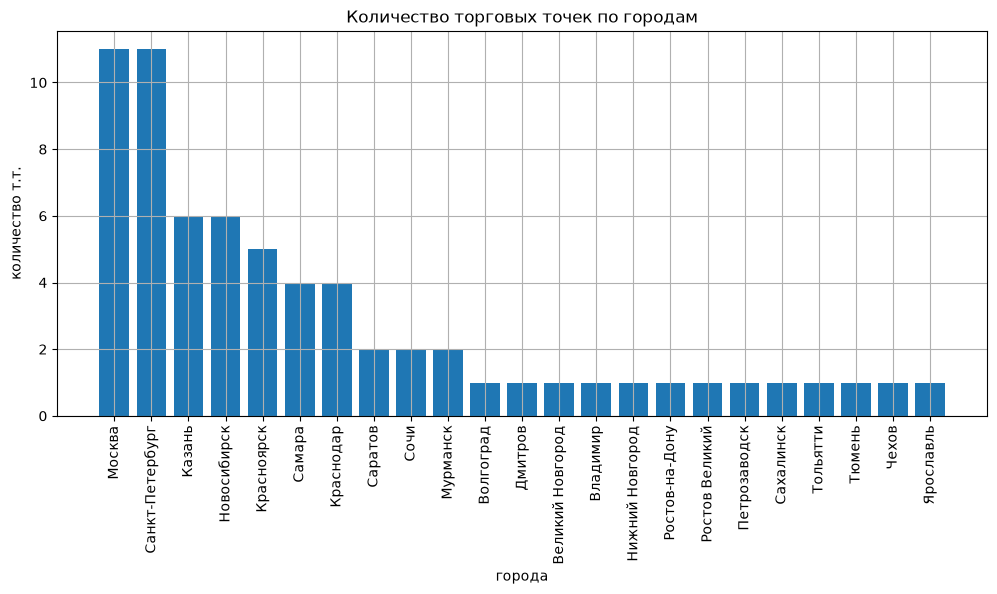

In [10]:
plt.figure(figsize = (12,5))
plt.bar(city_cnt['city'], city_cnt['city_count'])
plt.title('Количество торговых точек по городам')
plt.xlabel('города')
plt.ylabel('количество т.т.')
plt.xticks(rotation = 90)
plt.grid()
plt.show()

Как видим, в большинстве городов 1 торговая точка. Больше всего - в Москве и в Санкт-Петербурге (11)

In [11]:
# Таблица с суммарными выплатами каждого клиента
client_all_sum = orders_clear.groupby('id_client')['amt_payment'].sum().reset_index()
client_all_sum

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0
...,...,...
28378,209630.0,6927.0
28379,209631.0,2090.0
28380,209632.0,2775.0
28381,209633.0,1673.0


In [12]:
# merge с clients, Nan -> 0
client_all_sum = client_all_sum.merge(clients_clear, on = 'id_client', how = 'right')
client_all_sum['amt_payment'] = np.where(client_all_sum['amt_payment'].isnull(),0,client_all_sum['amt_payment'])
client_all_sum

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453
...,...,...,...,...,...
55351,193038.0,5846.0,2022-07-09 00:31:25.196,0,1015
55352,244069.0,0.0,2022-08-08 00:12:31.319,1,991
55353,189084.0,7146.0,2022-06-29 04:34:42.610,1,439
55354,182758.0,13720.0,2022-06-13 11:28:37.856,1,573


In [13]:
# Добавляем информацию по городам
client_all_sum = client_all_sum.merge(regions, on = 'id_trading_point', how = 'inner')
client_all_sum

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54,Мурманск
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991,Казань
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015,Краснодар
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург
...,...,...,...,...,...,...
55351,193038.0,5846.0,2022-07-09 00:31:25.196,0,1015,Краснодар
55352,244069.0,0.0,2022-08-08 00:12:31.319,1,991,Казань
55353,189084.0,7146.0,2022-06-29 04:34:42.610,1,439,Казань
55354,182758.0,13720.0,2022-06-13 11:28:37.856,1,573,Санкт-Петербург


In [14]:
# Добавляем флаг по выплатам
client_all_sum['pay_flag'] = np.where(client_all_sum['amt_payment'] == 0,0,1)
client_all_sum

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,pay_flag
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54,Мурманск,0
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991,Казань,1
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015,Краснодар,0
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55351,193038.0,5846.0,2022-07-09 00:31:25.196,0,1015,Краснодар,1
55352,244069.0,0.0,2022-08-08 00:12:31.319,1,991,Казань,0
55353,189084.0,7146.0,2022-06-29 04:34:42.610,1,439,Казань,1
55354,182758.0,13720.0,2022-06-13 11:28:37.856,1,573,Санкт-Петербург,1


In [15]:
# функция вычисления значение t-критерия (критерия Стьюдента) и p_value.
# printing - аргумент для активации print-ов
def t_test_calc(test, control, a = 0.05, printing = True):
    if printing == True:
        print(f'среднее тестовой группы: {round(test.mean(),4)}, среднее контрольной группы: {round(control.mean(),4)}')
    s, p = ttest_ind(test, control)
    if p < a and printing == True:
        print('Основываясь на t-критерии, разница между группами статистически значима')
    return s, p

In [16]:
# функция вычисления критерия Манна-Уитни и p_value
def whitney_test_calc(test, control, a = 0.05):
    print(f'медиана тестовой группы: {int(test.median())}, медиана контрольной группы: {int(control.median())}')
    s, p = mannwhitneyu(test, control)
    if p < a:
        print('Основываясь на критерии Манна-Уитни, разница между группами статистически значима')
    return s, p

In [17]:
# разбиваем клиентов по тестовой и контрольной группе
all_test_clients = client_all_sum[client_all_sum['nflag_test'] == 1]
all_control_clients = client_all_sum[client_all_sum['nflag_test'] == 0]

In [18]:
# все торговые точки, в которых в тестовой или в контрольной группе не было заплачено ни одного рубля ни одним клиентом.
zero_sum_points = []
for i in regions['id_trading_point']:
    if (all_test_clients[all_test_clients['id_trading_point'] == i]['amt_payment'].sum() == 0) or (all_control_clients[all_control_clients['id_trading_point'] == i]['amt_payment'].sum() == 0):
        zero_sum_points.append(i)
zero_sum_points

[1, 4, 7, 13, 23, 26, 46, 228, 603, 739, 800, 810, 866, 1015, 1099]

In [19]:
# все торговые точки, в которых пустует или контрольная, или тестовая группа.
empty_group_points = []
for i in regions['id_trading_point']:
    if (len(all_test_clients[all_test_clients['id_trading_point'] == i]) == 0) or (len(all_control_clients[all_control_clients['id_trading_point'] == i]) == 0):
        empty_group_points.append(i)
empty_group_points

[228, 603, 739, 800, 810, 866, 1015, 1099]

zero_sum_points содержит в себе все элементы из empty_group_points, что логично

In [20]:
# отчищаем таблицы от т.т. с пустыми выплатами
all_test_clients = all_test_clients[~all_test_clients['id_trading_point'].isin(zero_sum_points)]
all_control_clients = all_control_clients[~all_control_clients['id_trading_point'].isin(zero_sum_points)]

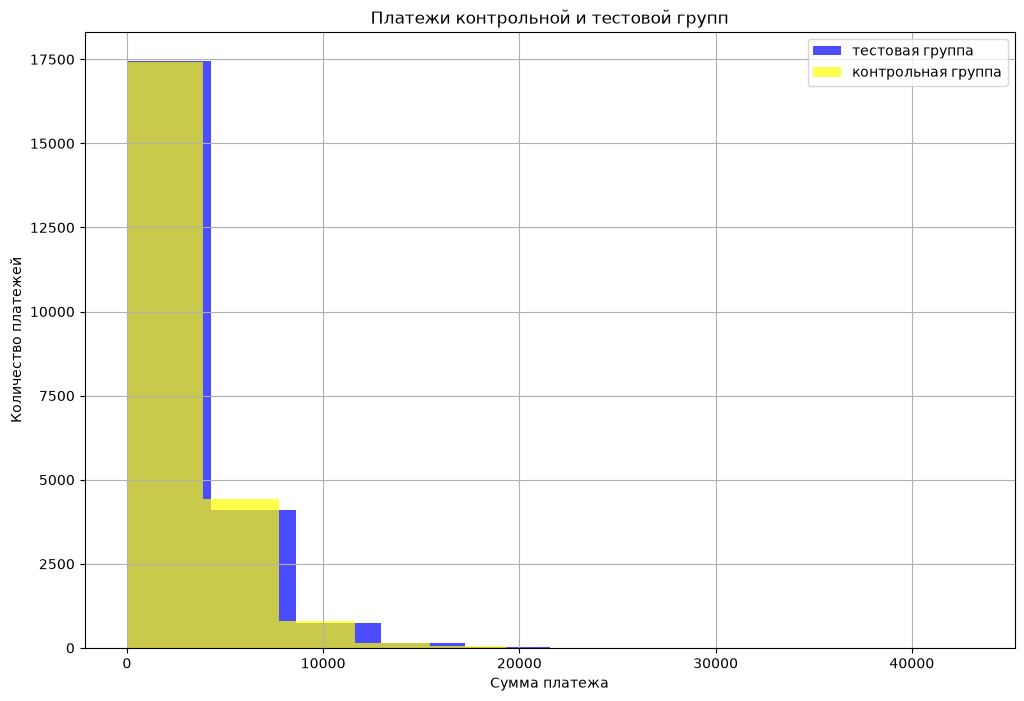

In [21]:
plt.figure(figsize = (12,8))
plt.hist(all_test_clients['amt_payment'], color = 'blue', label = 'тестовая группа', alpha = 0.7)
plt.hist(all_control_clients['amt_payment'], color = 'yellow', label = 'контрольная группа', alpha = 0.7)
plt.legend(loc = 'upper right')
plt.title('Платежи контрольной и тестовой групп')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество платежей')
plt.grid()
plt.show()

Из гистограммы видим, что и у тестовой группы, и у контрольной, абсолютное большинство платежей имеют размер менее 10000. Есть выплаты, которые доходят и до 40000, подробнее это можно увидеть в следующем графике.

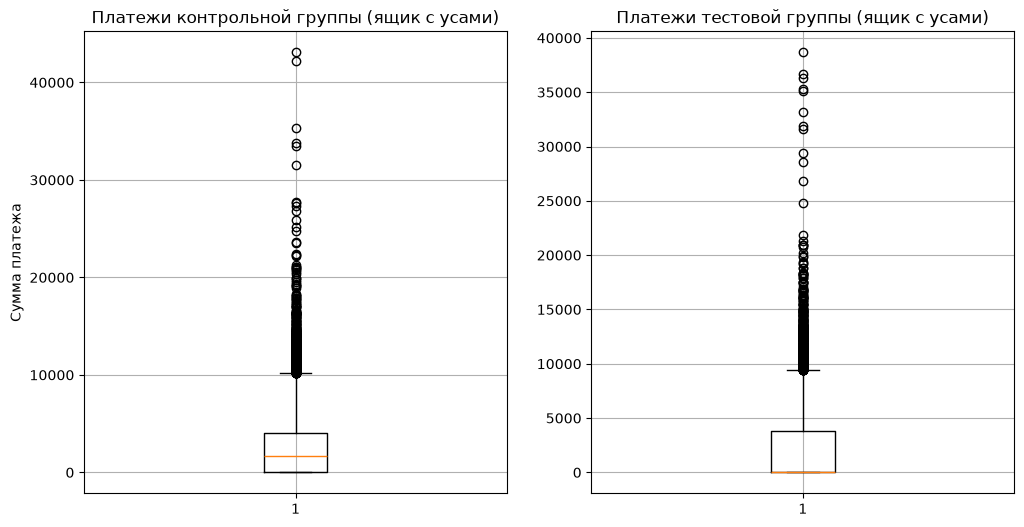

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
ax[0].boxplot(all_test_clients['amt_payment'])
ax[1].boxplot(all_control_clients['amt_payment'])
ax[0].set_title('Платежи контрольной группы (ящик с усами)')
ax[1].set_title('Платежи тестовой группы (ящик с усами)')
ax[0].set_ylabel('Сумма платежа')
ax[0].grid()
ax[1].grid()
plt.show()

Не будем удалять значения "вне усов", так как их довольно много, так что их влияние на выборку ощутимо

In [23]:
print("Платежи, t-критерий")
t_stat, p_value1 = t_test_calc(test = all_test_clients['amt_payment'], control = all_control_clients['amt_payment'])
print(f"Значение t-критерия = {t_stat}, p_value = {p_value1}")

Платежи, t-критерий
среднее тестовой группы: 2452.2773, среднее контрольной группы: 2189.1884
Основываясь на t-критерии, разница между группами статистически значима
Значение t-критерия = 9.456798235171377, p_value = 3.3214645838934085e-21


In [24]:
print("Конверсия, t-критерий")
t_stat, p_value1 = t_test_calc(test = all_test_clients['pay_flag'], control = all_control_clients['pay_flag'])
print(f"Значение t-критерия = {t_stat}, p_value = {p_value1}")

Конверсия, t-критерий
среднее тестовой группы: 0.5433, среднее контрольной группы: 0.4998
Основываясь на t-критерии, разница между группами статистически значима
Значение t-критерия = 9.282032730948323, p_value = 1.733807302756429e-20


In [25]:
print("Платежи, критерий Манна-Уитни")
mw_stat, p_value2 = whitney_test_calc(test = all_test_clients['amt_payment'], control = all_control_clients['amt_payment'])
print(f"Значение критерия Манна-Уитни = {mw_stat}, p_value = {p_value2}")

Платежи, критерий Манна-Уитни
медиана тестовой группы: 1669, медиана контрольной группы: 0
Основываясь на критерии Манна-Уитни, разница между группами статистически значима
Значение критерия Манна-Уитни = 270040116.0, p_value = 3.008345273971901e-24


Как видим, медиана контрольной группы по выплатам = 0, хотя отрицательных значений нет. Это означает, что более половины клиентов ничего не заплатили

В общем A/B-тестировании можно сделать вывод, что у тестовой группы статистически значимо больше и конверсия в платёж, и его размер (среднее и медиана), так что можно сказать, что в общем push-уведомления показывают себя намного лучше, чем баннеры, однако стоит рассмотреть результаты по каждому городу отдельно.

In [26]:
# список всех городов по убыванию количества торговых точек
cities = city_cnt['city']

In [27]:
# повторим вызов функций для каждого города
for city in cities:
    print(str(city).upper())

    test_data = all_test_clients[all_test_clients['city'] == city]
    control_data = all_control_clients[all_control_clients['city'] == city]

    if len(test_data) == 0 or len(control_data) == 0:
        print(f"В городе {city} есть пустые группы\n")
    else:
        print("Платежи, t-критерий")
        t_stat, p_value1 = t_test_calc(test = test_data['amt_payment'], control = control_data['amt_payment'])
        print(f"Значение t-критерия = {t_stat}, p_value = {p_value1}")

        print("Конверсия, t-критерий")
        t_stat, p_value1 = t_test_calc(test = test_data['pay_flag'], control = control_data['pay_flag'])
        print(f"Значение t-критерия = {t_stat}, p_value = {p_value1}")

        print("Платежи, критерий Манна-Уитни")
        mw_stat, p_value2 = whitney_test_calc(test = test_data['amt_payment'], control = control_data['amt_payment'])
        print(f"Значение критерия Манна-Уитни = {mw_stat}, p_value = {p_value2}\n")

МОСКВА
Платежи, t-критерий
среднее тестовой группы: 2367.9591, среднее контрольной группы: 1986.1806
Основываясь на t-критерии, разница между группами статистически значима
Значение t-критерия = 7.676511027843395, p_value = 1.7575494395557627e-14
Конверсия, t-критерий
среднее тестовой группы: 0.5435, среднее контрольной группы: 0.4879
Основываясь на t-критерии, разница между группами статистически значима
Значение t-критерия = 6.190312288026295, p_value = 6.194689260032596e-10
Платежи, критерий Манна-Уитни
медиана тестовой группы: 1725, медиана контрольной группы: 0
Основываясь на критерии Манна-Уитни, разница между группами статистически значима
Значение критерия Манна-Уитни = 20595574.5, p_value = 7.010591402203484e-16

САНКТ-ПЕТЕРБУРГ
Платежи, t-критерий
среднее тестовой группы: 2427.4625, среднее контрольной группы: 1913.5586
Основываясь на t-критерии, разница между группами статистически значима
Значение t-критерия = 8.759635784179547, p_value = 2.3198088937974243e-18
Конверсия, t

В городах Москва, Санкт-Петербург, Самара, Владимир - тестовая группа по всем критериям статистически значимо превосходит контрольную, рекомендуется внедрить систему push-уведомлений

В городах Казань, Красноярск, Краснодар, Саратов, Мурманск, Дмитров, Сахалинск, Тольятти - разница по всем критериям статистически не значима

В Сочи статистически значим только конверсия (тестовая выборка уступает контрольной)

В Волгограде статистически значимы только платежи (тестовая выборка уступает контрольной)

В Тюмене статистически значим t-критерий по конверсии в покупку и критерий Манна-Уитни по платежам (тестовая группа превосходит контрольную), рекомендуется внедрить систему push-уведомлений

В городах Новосибирск, Великий новгород, Нижний Новгород, Ростов-на-Дону, Ростов Великий, Петрозаводск, Чехов, Ярославль есть пустые группы, требуется больше наблюдений

In [28]:
# строим итоговую таблицу. первая колонка - отсортированные города, вторая - торговые точки.
fin_table = regions[~regions['id_trading_point'].isin(zero_sum_points)][['city', 'id_trading_point']].sort_values(['city'], ascending = True)

In [29]:
# строим дополнительную таблицу для клиентов из тестовой группы с суммарными выплатами, кол-ом клиентов и средними выплатами на клиента
additional_test_table =  all_test_clients.groupby(['id_trading_point']).agg(avg_payment_test = ('amt_payment', 'sum'), count_test = ('id_client', 'count')).reset_index()
additional_test_table['avg_payment_test'] = additional_test_table['avg_payment_test'] / additional_test_table['count_test']

In [30]:
# строим аналогичную таблицу для контрольной группы
additional_control_table =  all_control_clients.groupby(['id_trading_point']).agg(avg_payment_control = ('amt_payment', 'sum'), count_control = ('id_client', 'count')).reset_index()
additional_control_table['avg_payment_control'] = additional_control_table['avg_payment_control'] / additional_control_table['count_control']

In [31]:
# мерджим итоговую таблицу с дополнительными
fin_table = fin_table.merge(additional_test_table, on = 'id_trading_point', how = 'inner')
fin_table = fin_table.merge(additional_control_table, on = 'id_trading_point', how = 'inner')

In [32]:
# добавляем суммарное кол-во наблюдений
count_all = sum(fin_table['count_test']) + sum(fin_table['count_control'])
fin_table['count_all'] = count_all

In [33]:
# процент кол-ва наблюдений данной т.т. от всех наблюдений
fin_table['percent_count'] = (fin_table['count_test'] + fin_table['count_control']) / count_all * 100

In [34]:
# разница между средними платежами.
fin_table['diff'] = fin_table['avg_payment_test'] - fin_table['avg_payment_control']

In [35]:
# Рассчитываем стандартные отклонения платежей
sigma_map = all_test_clients.groupby('id_trading_point').agg(sigma_test = ('amt_payment', 'std')).reset_index()
fin_table = fin_table.merge(sigma_map, on = 'id_trading_point', how = 'inner')
sigma_map = all_control_clients.groupby('id_trading_point').agg(sigma_control = ('amt_payment', 'std')).reset_index()
fin_table = fin_table.merge(sigma_map, on = 'id_trading_point', how = 'inner')

In [36]:
fin_table['ttest'] = None
fin_table['pvalue_ttest'] = None

In [37]:
# все торговые точки
points = fin_table['id_trading_point']
len(points)

51

In [38]:
# вызываем функцию для расчёта тест-критерия на каждую т.т., printing = False
for point in points:
    test = all_test_clients[all_test_clients['id_trading_point'] == point]['amt_payment']
    control = all_control_clients[all_control_clients['id_trading_point'] == point]['amt_payment']
    s, p = t_test_calc(test, control, a = 0.05, printing = False)
    fin_table.loc[fin_table['id_trading_point'] == point, 'ttest'] = s
    fin_table.loc[fin_table['id_trading_point'] == point, 'pvalue_ttest'] = p

In [39]:
#добавляем флаг для определения вида исхода по каждой т.т.
fin_table['conclusion'] = None
fin_table['conclusion'] = np.where(fin_table['pvalue_ttest'] < 0.05, np.where(fin_table['diff'] > 0, 'положительный исход', 'отрицательный исход'), 'нейтральный исход')

In [40]:
round(fin_table.head(), 2)

,city,id_trading_point,avg_payment_test,count_test,avg_payment_control,count_control,count_all,percent_count,diff,sigma_test,sigma_control,ttest,pvalue_ttest,conclusion
0,Владимир,11,2547.22,509,2108.61,608,45318,2.46,438.61,3023.70,2663.04,2.576955,0.010095,положительный исход
1,Волгоград,66,2288.87,657,2601.76,703,45318,3.00,-312.89,2682.57,2830.19,-2.089272,0.036869,отрицательный исход
2,Дмитров,2,579.33,78,483.45,71,45318,0.33,95.88,1860.76,1654.92,0.331052,0.741076,нейтральный исход
3,Казань,991,3249.28,270,2452.99,294,45318,1.24,796.30,4719.59,3633.94,2.255258,0.024501,положительный исход
4,Казань,699,2422.29,482,2574.35,494,45318,2.15,-152.07,3906.82,4082.85,-0.594254,0.55248,нейтральный исход


In [41]:
# Создаём Excel-файл
output_path = 'AB_test_calc.xlsx'

with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
    # Перебираем все уникальные лейблы
    for label in fin_table['conclusion'].unique():
        df_label = fin_table[fin_table['conclusion'] == label]
        sheet_name = label.replace(' ', '_')  # замена пробелов на подчёркивания для корректности
        df_label.to_excel(writer, sheet_name=sheet_name, index=False)

print('Файл сохранён')

Файл сохранён
